# Where to open a café in central Moscow?

**Applied Data Science Capstone (IBM / Coursera): the Battle of the Neighbourhoods, Moscow edition.**

This notebook completes the project started in 2019. [Notebook 01](01_data_collection_moscow_open_data.ipynb)
built a grid of candidate locations around Red Square and collected Moscow Open Data layers;
[notebook 02](02_foursquare_central_districts.ipynb) explored the central districts with Foursquare.
Here the pieces come together into a location recommendation.

1. [Introduction: the business problem](#1.-Introduction:-the-business-problem)
2. [Data](#2.-Data)
3. [Methodology](#3.-Methodology)
4. [Exploratory analysis](#4.-Exploratory-analysis)
5. [Neighbourhood typology](#5.-Neighbourhood-typology)
6. [Demand model](#6.-Demand-model)
7. [Opportunity score and shortlist](#7.-Opportunity-score-and-shortlist)
8. [Results and discussion](#8.-Results-and-discussion)
9. [Conclusion](#9.-Conclusion)

## 1. Introduction: the business problem

Central Moscow is one of the densest café markets in Europe: within 6 km of Red Square
OpenStreetMap lists almost 4,000 cafés and restaurants, and on many streets there is a coffee
shop on every corner. Opening one more café there is mostly a bet on the location. A good site
sits on a steady flow of people (commuters coming out of the metro, shoppers, visitors of
hairdressers and repair shops, students) but is not already crowded with competitors that
absorb that flow.

**Stakeholder.** An entrepreneur or a franchise developer who plans a new café (coffee,
pastries, light meals) in central Moscow and needs a short list of places worth a field visit
and a rent search.

**Question.** Which locations within 6 km of Red Square have the footfall generators that
usually support many cafés, yet host noticeably fewer cafés and restaurants than comparable
places?

**Approach.** The area is covered by 364 hexagonal cells about 590 m across. For every cell we
count what lies within 300 m: competitors, metro exits, bus stops, parking spaces, shops,
consumer services, gyms, universities. A model trained on all cells learns how many cafés and
restaurants a place with a given mix of footfall generators usually has; cells with far fewer
competitors than expected are under-served. The shortlist keeps the under-served cells that are
close to the metro and already have street retail around them.

## 2. Data

| Layer | Source | Used as |
|---|---|---|
| Candidate locations | Hexagonal grid within 6 km of Red Square, 600 m step (notebook 01); addresses from the Yandex Geocoder | units of analysis |
| Metro entrances and exits | [data.mos.ru](https://data.mos.ru), 2019 | footfall: exits within 300 m, distance to the nearest exit |
| Surface transport stops | data.mos.ru, 2019 | footfall: stops within 300 m |
| Paid street parking | data.mos.ru, 2019 | accessibility by car: parking spaces within 300 m |
| Shops | data.mos.ru shopping register, 2019 | footfall: shops within 300 m |
| Consumer services | data.mos.ru, 2019 | footfall: hairdressers, dry cleaners, repairs... within 300 m |
| Fitness | data.mos.ru, 2019 | footfall: gyms within 300 m |
| Cafés, restaurants, fast food, bars | [OpenStreetMap](https://www.openstreetmap.org/copyright), Overpass API | competitors (cafés and restaurants) and the rest of the catering scene |
| Universities and colleges | OpenStreetMap | footfall: students |

Notes on the data:

* The catering register used in 2019 (`df_cafe.csv`, restaurants and cafés from data.mos.ru)
  was never committed and its Dropbox copy is gone, while data.mos.ru does not answer outside
  Russia. Catering therefore comes from an OpenStreetMap snapshot
  (`scripts/fetch_osm_data.py`). To stay close to the 2019 definition (notebook 01 kept only
  the *кафе* and *ресторан* types of the register), **competitors are OSM cafés and restaurants**;
  fast food and bars are described but not counted as competitors.
* The education register step of notebook 01 was never finished, so universities and
  colleges also come from OpenStreetMap.
* The shops layer is the part of the 60,320-shop register saved in 2019: clothing, food, general
  goods, supermarkets and the branded part of flower and specialised stores, 22,109 shops.
  A duplicate file (`df_othernotbrandedfood.csv` held the general goods again) was dropped.
* The fitness register lists gym halls, several per club; they are merged into 385 facilities.
  It covers mostly municipal sports centres.
* The cinema register holds only 14 municipal cinemas, too few to describe 364 cells, so it is
  not used.
* The layers are seven years apart (2019 vs 2026); see the discussion for what this means.

In [1]:
import json
import sys
from html import escape
from pathlib import Path

import branca.colormap as bcm
import folium
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium.plugins import HeatMap
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import d2_tweedie_score, silhouette_score
from sklearn.model_selection import KFold, PredefinedSplit, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from moscow_cafes import data  # noqa: E402
from moscow_cafes.features import RADIUS_M, build_features  # noqa: E402
from moscow_cafes.geo import RED_SQUARE, distance_from, grid_hexagons, nearest, to_xy, xy_array  # noqa: E402

REPORT = ROOT / "report"
FIGURES = REPORT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 2)

In [2]:
# Chart styling: a light surface, hairline axes, and one colour job per chart:
# sequential blue for magnitude, red <-> gray <-> blue for "fewer / more than expected".
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, RED, NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#f0efec"
BLUE_STEPS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("fewer_more", [RED, NEUTRAL, BLUE])
HALO = [patheffects.withStroke(linewidth=3, foreground=SURFACE)]  # keeps labels legible over map tiles

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "font.size": 10,
        "legend.frameon": False,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png")

### Loading the layers

In [3]:
cells = data.load_candidates()
layers = {
    "catering": data.load_catering(),
    "metro": data.load_metro_exits(),
    "bus": data.load_bus_stops(),
    "parking": data.load_parking(),
    "shops": data.load_shops(),
    "services": data.load_services(),
    "fitness": data.load_fitness(),
    "education": data.load_education(),
}
osm_meta = json.loads((ROOT / "data" / "osm" / "osm_meta.json").read_text(encoding="utf-8"))
osm_date = osm_meta["catering"]["timestamp_osm_base"][:10]

pd.DataFrame(
    [
        ("Candidate locations", len(cells), "grid of notebook 01", "2019"),
        ("Metro entrances and exits", len(layers["metro"]), "data.mos.ru, whole city", "2019"),
        ("Surface transport stops", len(layers["bus"]), "data.mos.ru, whole city", "2019"),
        ("Paid parking zones", len(layers["parking"]), "data.mos.ru, whole city", "2019"),
        ("Shops", len(layers["shops"]), "data.mos.ru, whole city", "2019"),
        ("Consumer services", len(layers["services"]), "data.mos.ru, whole city", "2019"),
        ("Fitness facilities", len(layers["fitness"]), "data.mos.ru, whole city", "2019"),
        ("Catering venues", len(layers["catering"]), "OpenStreetMap, 7 km around Red Square", osm_date),
        ("Universities and colleges", len(layers["education"]), "OpenStreetMap, 7 km around Red Square", osm_date),
    ],
    columns=["Layer", "Records", "Coverage", "Vintage"],
)

,Layer,Records,Coverage,Vintage
0,Candidate locations,364,grid of notebook 01,2019
1,Metro entrances and exits,1067,"data.mos.ru, whole city",2019
2,Surface transport stops,11507,"data.mos.ru, whole city",2019
3,Paid parking zones,9254,"data.mos.ru, whole city",2019
4,Shops,22109,"data.mos.ru, whole city",2019
5,Consumer services,14540,"data.mos.ru, whole city",2019
6,Fitness facilities,385,"data.mos.ru, whole city",2019
7,Catering venues,6729,"OpenStreetMap, 7 km around Red Square",2026-09-28
8,Universities and colleges,283,"OpenStreetMap, 7 km around Red Square",2026-09-28


## 3. Methodology

1. **A metric projection.** All coordinates are projected to UTM zone 37N (EPSG:32637), the
   zone Moscow lies in. Notebook 01 used zone 33, whose central meridian is 22.6° west of Moscow;
   the check below shows what that did to distances.
2. **Feature engineering.** For each of the 364 candidate cells: the number of objects of every
   layer within 300 m (about four minutes on foot), the parking capacity within 300 m, and the
   distances to the nearest metro exit and to Red Square.
3. **Exploratory analysis.** The catering scene, its chains, and how competitor density relates
   to each footfall generator (Spearman correlation).
4. **Neighbourhood typology.** k-means on the standardised features groups the cells into a few
   types of urban fabric, which helps to read the maps and the shortlist.
5. **Demand model.** A Poisson regression predicts the number of competitors from the footfall
   generators alone, with gradient boosting as a flexible benchmark. Models are compared with
   **spatial cross-validation**: the city is cut into 2 × 2 km blocks and whole blocks are held
   out, so a cell is never predicted by its immediate neighbours. The out-of-fold prediction is
   the "expected" number of competitors of every cell.
6. **Opportunity score.** The standardised gap between the actual and the expected number of
   competitors, with the variance of a negative binomial distribution because the counts are
   overdispersed. The most negative scores are the under-served cells.
7. **Shortlist.** Cells with a metro exit within 500 m, at least 10 shops or services around them
   (street retail exists, so do commercial premises) and at least median expected demand, ranked
   by the opportunity score. The pipeline runs with 250, 300 and 400 m catchments and the scores
   are averaged, so the ranking does not hinge on one catchment size.

In [4]:
features = build_features(cells, **layers)

# Distances from Red Square as stored by notebook 01 (UTM zone 33) versus zone 37.
legacy = pd.read_csv(ROOT / "data" / "mos_open_data" / "df_locations.csv", index_col=0)["Distance from center"]
stretch = (legacy / features["center_distance"]).mean() - 1
print(f"UTM zone 33 overstated distances by {stretch:.1%}: the farthest cell is "
      f"{legacy.max():,.0f} m away in zone 33 and {features['center_distance'].max():,.0f} m in reality.")

features.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

UTM zone 33 overstated distances by 2.4%: the farthest cell is 5,992 m away in zone 33 and 5,851 m in reality.


,mean,std,min,25%,50%,75%,max
cafes,6.34,7.41,0.0,1.00,4.00,9.00,61.00
restaurants,3.80,5.51,0.0,0.00,2.00,5.00,35.00
competitors,10.14,11.77,0.0,2.00,6.00,14.00,75.00
fast_food,3.47,4.97,0.0,0.00,2.00,4.00,32.00
bars,1.91,4.21,0.0,0.00,0.00,2.00,32.00
metro_exits,0.74,1.99,0.0,0.00,0.00,0.00,15.00
metro_distance,570.96,316.66,3.6,334.18,545.12,763.02,1648.36
bus_stops,4.18,2.97,0.0,2.00,4.00,6.00,17.00
parking_spaces,131.87,107.81,0.0,39.00,121.50,191.50,510.00
shops,13.36,70.66,0.0,1.00,4.00,9.00,1306.00


## 4. Exploratory analysis

### The catering scene

In [5]:
catering = layers["catering"]
central = catering[distance_from(catering, *RED_SQUARE) <= 6000]
composition = central["amenity"].value_counts().rename("venues").to_frame()
composition["share, %"] = (100 * composition["venues"] / composition["venues"].sum()).round(1)

competitors = central[central["is_competitor"]]
chain_counts = competitors["chain"].value_counts()
chains = chain_counts[chain_counts >= 5]
print(f"Within 6 km of Red Square: {len(central):,} catering venues, of which {len(competitors):,} "
      f"cafés and restaurants (the competitors).")
print(f"{len(chains)} chains have 5 or more outlets there and run "
      f"{competitors['chain'].isin(chains.index).mean():.0%} of the cafés and restaurants.")
composition

Within 6 km of Red Square: 6,121 catering venues, of which 3,933 cafés and restaurants (the competitors).
59 chains have 5 or more outlets there and run 22% of the cafés and restaurants.


,venues,"share, %"
amenity,,
cafe,2459,40.2
restaurant,1474,24.1
fast_food,1353,22.1
bar,607,9.9
pub,130,2.1
ice_cream,60,1.0
food_court,38,0.6


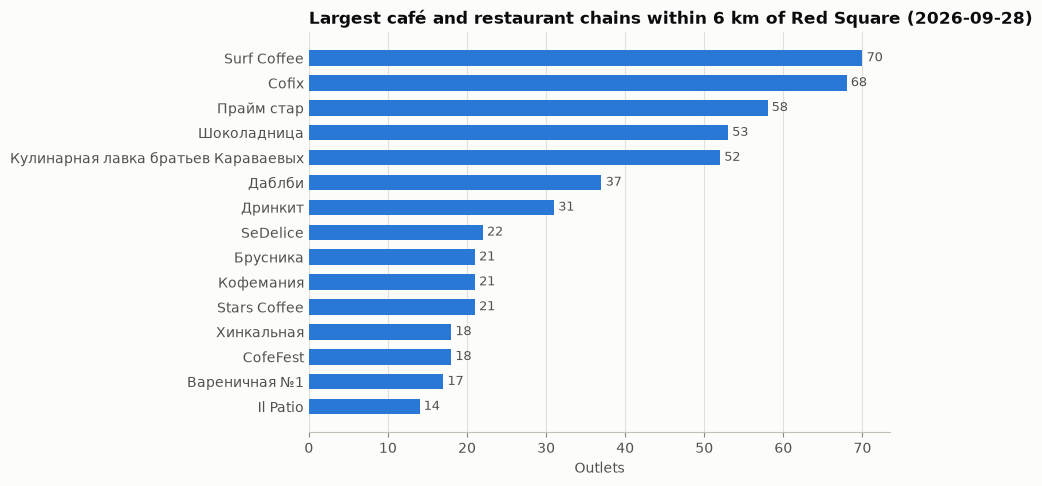

In [6]:
top_chains = chain_counts.head(15).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.barh(top_chains.index, top_chains.values, color=BLUE, height=0.62)
ax.bar_label(bars, padding=3, color=INK_2, fontsize=9)
ax.set_title(f"Largest café and restaurant chains within 6 km of Red Square ({osm_date})")
ax.set_xlabel("Outlets")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig1_top_chains")
plt.show()

The largest chains sell coffee (Surf Coffee, Cofix, Prime, which the 2019 cleaning rules call
*Прайм стар*, Шоколадница, Даблби), next to the culinary shops of the Karavaev brothers. Yet chains
with five or more outlets run only about a fifth of the cafés and restaurants: the market is
mostly independent venues.

### Where the competitors are

The candidate cells are drawn as the hexagons of the grid; the static maps use kilometres from
Red Square as coordinates.

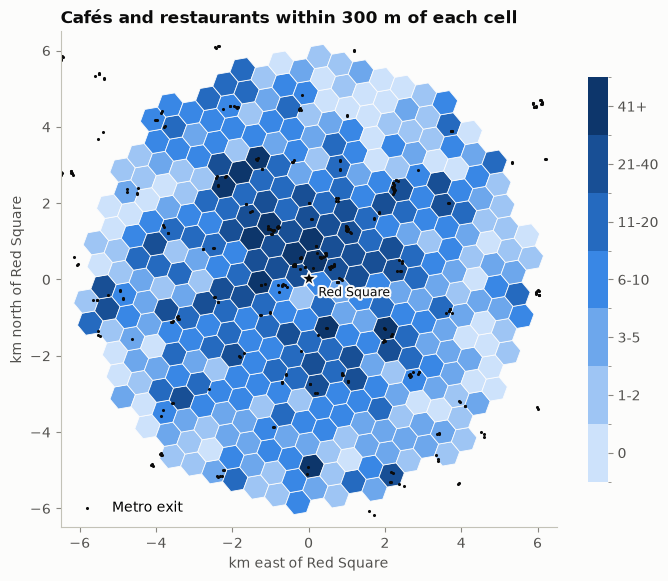

In [7]:
HEX_LATLON = grid_hexagons(cells["lat"], cells["lon"])
hex_x, hex_y = to_xy(HEX_LATLON[..., 0], HEX_LATLON[..., 1])
center_x, center_y = to_xy(*RED_SQUARE)
HEX_KM = np.stack([(hex_x - center_x) / 1000, (hex_y - center_y) / 1000], axis=-1)
CELL_KM = HEX_KM.mean(axis=1)
EXTENT_KM = 6.5


def hex_map(ax, values, cmap, norm, title, **collection_kwargs):
    """Draw the grid as a choropleth of `values` (one per cell, in cell order)."""
    tiles = PolyCollection(
        HEX_KM, array=np.asarray(values, dtype=float), cmap=cmap, norm=norm,
        edgecolor=SURFACE, linewidth=0.6, **collection_kwargs,
    )
    ax.add_collection(tiles)
    ax.set_xlim(-EXTENT_KM, EXTENT_KM)
    ax.set_ylim(-EXTENT_KM, EXTENT_KM)
    ax.set_aspect("equal")
    ax.plot(0, 0, marker="*", markersize=12, color=INK, markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.annotate("Red Square", (0, 0), xytext=(7, -12), textcoords="offset points", color=INK, fontsize=9,
                path_effects=HALO)
    ax.set_xlabel("km east of Red Square")
    ax.set_ylabel("km north of Red Square")
    ax.set_title(title)
    return tiles


metro = layers["metro"]
metro_xy = xy_array(metro)
metro_km = (metro_xy - [center_x, center_y]) / 1000
metro_km = metro_km[np.abs(metro_km).max(axis=1) < EXTENT_KM]

bins = [0, 1, 3, 6, 11, 21, 41, 1000]
fig, ax = plt.subplots(figsize=(8, 7))
tiles = hex_map(ax, features["competitors"], ListedColormap(BLUE_STEPS), BoundaryNorm(bins, len(BLUE_STEPS)),
                "Cafés and restaurants within 300 m of each cell")
ax.scatter(*metro_km.T, s=5, color=INK, linewidths=0, label="Metro exit")
colorbar = fig.colorbar(tiles, ax=ax, shrink=0.75, ticks=[0.5, 2, 4.5, 8.5, 16, 31, 520])
colorbar.ax.set_yticklabels(["0", "1-2", "3-5", "6-10", "11-20", "21-40", "41+"])
colorbar.outline.set_visible(False)
ax.legend(loc="lower left")
save(fig, "fig2_competitors_map")
plt.show()

The same picture on an interactive map: the heat map shows the competitors, the grey hexagons are
the candidate cells, the dots are metro exits. (GitHub does not render these maps; open the
notebook in [nbviewer](https://nbviewer.org/github/petro1eum/capstone/blob/master/notebooks/03_cafe_location_analysis.ipynb)
or run it locally.)

In [8]:
def base_map():
    fmap = folium.Map(location=RED_SQUARE, zoom_start=12, tiles="OpenStreetMap", control_scale=True)
    folium.Marker(RED_SQUARE, tooltip="Red Square", icon=folium.Icon(color="gray", icon="star")).add_to(fmap)
    return fmap


def hex_layer(table, fill, tooltip_fields, tooltip_aliases, name, opacity=0.6):
    """GeoJSON layer of the grid hexagons; `table` is indexed by cell, `fill` holds hex colours."""
    records = json.loads(table[tooltip_fields].to_json(orient="records", force_ascii=False))
    features_geojson = []
    for cell_id, record in zip(table.index, records, strict=True):
        ring = [[lon, lat] for lat, lon in HEX_LATLON[cells.index.get_loc(cell_id)]]
        features_geojson.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [ring + [ring[0]]]},
            "properties": {**{k: escape(v) if isinstance(v, str) else v for k, v in record.items()},
                           "fill": fill.loc[cell_id]},
        })
    return folium.GeoJson(
        {"type": "FeatureCollection", "features": features_geojson},
        name=name,
        style_function=lambda f: {"fillColor": f["properties"]["fill"], "fillOpacity": opacity,
                                  "color": SURFACE, "weight": 0.8},
        highlight_function=lambda f: {"weight": 2.5, "color": INK},
        tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, sticky=True),
    )


overview = cells[["address"]].join(features[["competitors", "metro_exits", "shops", "services"]])
grid_map = base_map()
hex_layer(overview, pd.Series(NEUTRAL, index=overview.index), list(overview.columns),
          ["Address", "Cafés and restaurants", "Metro exits", "Shops", "Services"], "Candidate cells",
          opacity=0.3).add_to(grid_map)
HeatMap(competitors[["lat", "lon"]].to_numpy().tolist(), name="Competitors", radius=12, blur=15,
        min_opacity=0.25).add_to(grid_map)
central_metro = metro[distance_from(metro, *RED_SQUARE) <= 6500]
metro_layer = folium.FeatureGroup(name="Metro exits")
for _, exit_ in central_metro.iterrows():
    folium.CircleMarker([exit_["lat"], exit_["lon"]], radius=2, color=INK, weight=1, fill=True,
                        fill_opacity=1, tooltip=exit_["name"]).add_to(metro_layer)
metro_layer.add_to(grid_map)
folium.LayerControl(collapsed=False).add_to(grid_map)
grid_map

Competitors crowd inside the Garden Ring and along the radial streets, and thin out towards the
Third Ring Road, apart from hot spots around big transport hubs. Which footfall generators go
together with them?

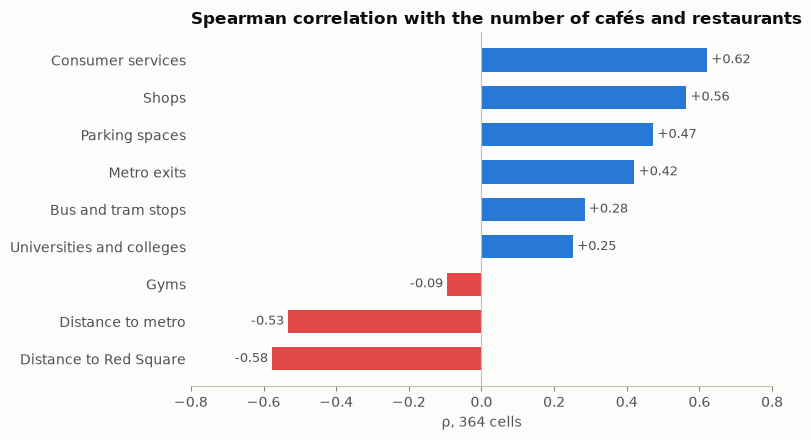

,Spearman ρ
Distance to Red Square,-0.58
Distance to metro,-0.53
Gyms,-0.09
Universities and colleges,0.25
Bus and tram stops,0.28
Metro exits,0.42
Parking spaces,0.47
Shops,0.56
Consumer services,0.62


In [9]:
drivers = ["metro_exits", "metro_distance", "bus_stops", "parking_spaces", "shops", "services",
           "fitness", "education", "center_distance"]
labels = {
    "metro_exits": "Metro exits", "metro_distance": "Distance to metro", "bus_stops": "Bus and tram stops",
    "parking_spaces": "Parking spaces", "shops": "Shops", "services": "Consumer services", "fitness": "Gyms",
    "education": "Universities and colleges", "center_distance": "Distance to Red Square",
}
rho = features[drivers].corrwith(features["competitors"], method="spearman").sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.barh([labels[d] for d in rho.index], rho.values, color=[BLUE if v > 0 else RED for v in rho.values],
               height=0.62)
ax.bar_label(bars, fmt="%+.2f", padding=3, color=INK_2, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=0.8)
ax.set_xlim(-0.8, 0.8)
ax.set_title("Spearman correlation with the number of cafés and restaurants")
ax.set_xlabel("ρ, 364 cells")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig3_correlations")
plt.show()
rho.rename(index=labels).to_frame("Spearman ρ")

Competitors go together with consumer services, shops and parking (all mark streets with
ground-floor commerce), and they fall with the distance to the metro and to Red Square. Bus stops
and universities matter less; the municipal gyms of the fitness register sit in residential areas
and have no relation to cafés at all.

## 5. Neighbourhood typology

k-means on the standardised features (counts log-transformed, distances in km). The silhouette
score is low for every k, which is normal for a city: urban fabric changes gradually rather than
in separated clumps. k = 2 splits the cells only into "busy" and "quiet", so k = 4, where the
inertia curve bends and the clusters are still easy to name, is used to describe the area.

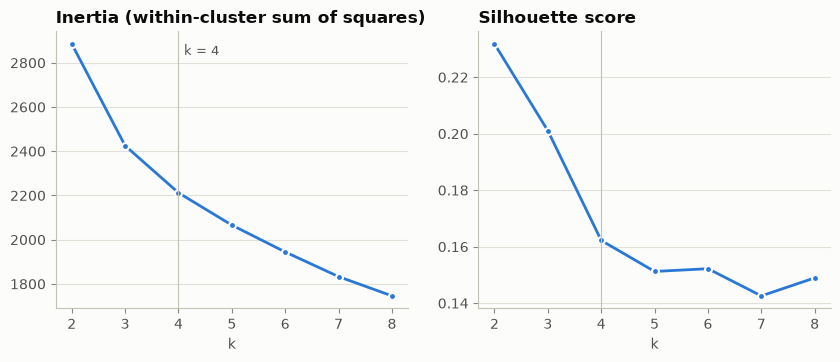

k,2,3,4,5,6,7,8
inertia,2885.42,2425.08,2212.05,2065.78,1944.32,1832.87,1745.74
silhouette,0.23,0.20,0.16,0.15,0.15,0.14,0.15


In [10]:
typology_columns = ["competitors", "fast_food", "bars", "metro_exits", "bus_stops", "parking_spaces",
                    "shops", "services", "education"]
typology_input = np.log1p(features[typology_columns]).assign(
    metro_distance_km=features["metro_distance"] / 1000,
    center_distance_km=features["center_distance"] / 1000,
)
Z = StandardScaler().fit_transform(typology_input)
k_values = list(range(2, 9))
kmeans_fits = {k: KMeans(n_clusters=k, n_init=20, random_state=0).fit(Z) for k in k_values}
k_scores = pd.DataFrame(
    {"inertia": [kmeans_fits[k].inertia_ for k in k_values],
     "silhouette": [silhouette_score(Z, kmeans_fits[k].labels_) for k in k_values]},
    index=pd.Index(k_values, name="k"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, column, title in zip(
    axes, k_scores.columns, ["Inertia (within-cluster sum of squares)", "Silhouette score"], strict=True
):
    ax.plot(k_scores.index, k_scores[column], color=BLUE, linewidth=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvline(4, color=AXIS, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
axes[0].annotate("k = 4", (4, k_scores["inertia"].max()), xytext=(4, 0), textcoords="offset points",
                 color=INK_2, fontsize=9, va="top")
save(fig, "fig4_kmeans_selection")
plt.show()
k_scores.round(3).T

In [11]:
K = 4
cluster_ids = pd.Series(kmeans_fits[K].labels_, index=cells.index)
profile = features.groupby(cluster_ids).median()

# Name the clusters by their profile, so the names do not depend on k-means label numbers.
hubs = profile["metro_exits"].idxmax()
quiet = (profile["shops"] + profile["services"]).idxmin()
central_id, residential_id = sorted(set(profile.index) - {hubs, quiet}, key=lambda c: profile.loc[c, "center_distance"])
CLUSTER_NAMES = {
    hubs: "Transit hubs",
    central_id: "Central neighbourhoods",
    residential_id: "Residential belt",
    quiet: "Parks, rail and industrial land",
}
assert len(set(CLUSTER_NAMES)) == K
CLUSTER_ORDER = ["Transit hubs", "Central neighbourhoods", "Residential belt", "Parks, rail and industrial land"]
CLUSTER_COLORS = dict(zip(CLUSTER_ORDER, [BLUE, ORANGE, AQUA, "#d9d8d2"], strict=True))
cluster = cluster_ids.map(CLUSTER_NAMES)

cluster_profile = features.groupby(cluster).median().reindex(CLUSTER_ORDER)
cluster_profile.insert(0, "cells", cluster.value_counts())
cluster_profile[["cells", "competitors", "fast_food", "bars", "metro_exits", "metro_distance", "bus_stops",
                 "parking_spaces", "shops", "services", "education", "center_distance"]].round(0).astype(int)

,cells,competitors,fast_food,bars,metro_exits,metro_distance,bus_stops,parking_spaces,shops,services,education,center_distance
Transit hubs,52,23,10,3,4,149,6,142,18,15,1,2885
Central neighbourhoods,82,16,3,2,0,441,4,188,6,11,1,2520
Residential belt,152,4,1,0,0,601,4,132,4,4,0,4471
"Parks, rail and industrial land",78,1,0,0,0,747,1,0,0,0,0,5107


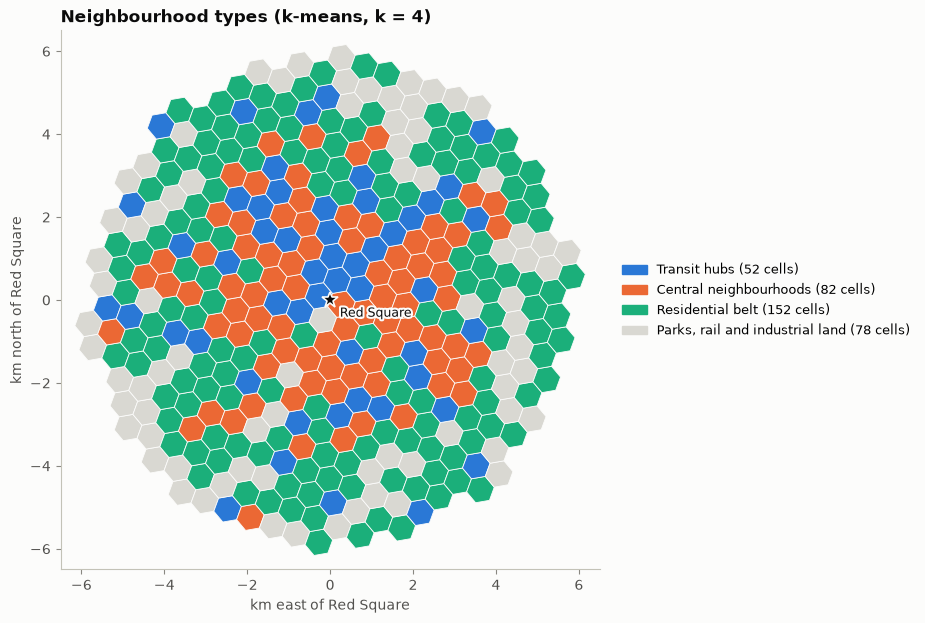

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
cluster_codes = cluster.map({name: i for i, name in enumerate(CLUSTER_ORDER)})
hex_map(ax, cluster_codes, ListedColormap([CLUSTER_COLORS[n] for n in CLUSTER_ORDER]),
        BoundaryNorm(np.arange(-0.5, K), K), "Neighbourhood types (k-means, k = 4)")
ax.legend(handles=[Patch(color=CLUSTER_COLORS[n], label=f"{n} ({(cluster == n).sum()} cells)") for n in CLUSTER_ORDER],
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
save(fig, "fig5_typology_map")
plt.show()

* **Transit hubs**: cells around major metro stations and on the main shopping streets, from
  Tverskaya and Nikolskaya to Sukharevskaya, Begovaya and Proletarskaya, with several exits within
  300 m, the most shops and services and the densest catering, fast food included.
* **Central neighbourhoods**: the historic centre and its surroundings, a couple of kilometres
  from Red Square: many cafés, restaurants and bars, lots of paid parking, the metro a few
  hundred metres away.
* **Residential belt**: the ring between the Garden Ring and the Third Ring Road, with modest
  retail and a handful of cafés per cell.
* **Parks, rail and industrial land**: Sokolniki, Petrovsky and Krasnaya Presnya parks, the
  Vagankovskoye, Kalitnikovskoye and Danilovskoye cemeteries, rail land around the Three Stations
  and Paveletsky, former factories: hardly any shops, services or parking, and nowhere to open a café.

In [13]:
typology_map = base_map()
typology_table = cells[["address"]].assign(type=cluster).join(
    features[["competitors", "metro_exits", "shops", "services"]])
hex_layer(typology_table, cluster.map(CLUSTER_COLORS), list(typology_table.columns),
          ["Address", "Type", "Cafés and restaurants", "Metro exits", "Shops", "Services"],
          "Neighbourhood types", opacity=0.55).add_to(typology_map)
typology_map

## 6. Demand model

The model predicts the number of competitors of a cell from its footfall generators only: metro
exits, bus stops, parking, shops, services, gyms, universities, and the distances to the metro and
to Red Square. Catering itself is left out of the inputs, because it is what we want to explain.
Counts enter as `log(1 + x)` (the tenth shop adds less than the first), capped at the 99th
percentile: one cell holds the Dubrovka clothing market with 1,306 registered stalls.

In [14]:
COUNT_DRIVERS = ["metro_exits", "bus_stops", "parking_spaces", "shops", "services", "fitness", "education"]


def design_matrix(features, distances="linear"):
    """Model inputs: log counts of the footfall generators and the two distances."""
    X = pd.DataFrame(index=features.index)
    for column in COUNT_DRIVERS:
        X[column] = np.log1p(features[column].clip(upper=features[column].quantile(0.99)))
    for column in ["metro_distance", "center_distance"]:
        km = features[column] / 1000
        X[f"{column}_km"] = np.log(km) if distances == "log" else km
    return X


# Spatial cross-validation: the cells are grouped into 2 x 2 km blocks and the blocks are dealt at
# random into 6 folds. RandomState and PredefinedSplit keep the folds the same in every library version.
BLOCK_M = 2000
block_xy = np.floor(xy_array(cells) / BLOCK_M).astype(int)
blocks = np.unique(block_xy, axis=0, return_inverse=True)[1].ravel()
cell_fold = (np.random.RandomState(0).permutation(blocks.max() + 1) % 6)[blocks]
spatial_cv = PredefinedSplit(cell_fold)


def glm(alpha):
    return make_pipeline(StandardScaler(), PoissonRegressor(alpha=alpha, max_iter=2000))


def boosting():
    return HistGradientBoostingRegressor(loss="poisson", learning_rate=0.03, max_iter=300, max_depth=3,
                                         min_samples_leaf=20, random_state=0)


def out_of_fold(model, X, y, cv=spatial_cv):
    return pd.Series(cross_val_predict(model, X, y, cv=cv), index=X.index)


def d2(y, prediction):
    """Share of the Poisson deviance explained, the R² of count models."""
    return d2_tweedie_score(y, prediction, power=1)


y = features["competitors"]
X_linear, X_log = design_matrix(features), design_matrix(features, distances="log")
fold_sizes = np.bincount(cell_fold)
print(f"{blocks.max() + 1} spatial blocks in 6 folds of {fold_sizes.min()}-{fold_sizes.max()} cells")

alpha_scores = pd.Series({a: d2(y, out_of_fold(glm(a), X_linear, y)) for a in [0.1, 0.3, 1, 3, 10]})
ALPHA = alpha_scores.idxmax()
print("GLM regularisation, D² by alpha:", alpha_scores.round(3).to_dict(), "-> alpha =", ALPHA)

38 spatial blocks in 6 folds of 46-72 cells


GLM regularisation, D² by alpha: {0.1: 0.573, 0.3: 0.575, 1.0: 0.579, 3.0: 0.576, 10.0: 0.535} -> alpha = 1.0


In [15]:
predictions = {
    "Poisson GLM, log distances": out_of_fold(glm(ALPHA), X_log, y),
    "Poisson GLM, linear distances": out_of_fold(glm(ALPHA), X_linear, y),
    "Gradient boosting, Poisson loss": out_of_fold(boosting(), X_linear, y),
}
predictions["Average of the GLM and boosting"] = (
    predictions["Poisson GLM, linear distances"] + predictions["Gradient boosting, Poisson loss"]
) / 2
model_comparison = pd.Series({name: d2(y, p) for name, p in predictions.items()}, name="D², spatial CV").to_frame()
random_cv_d2 = d2(y, out_of_fold(glm(ALPHA), X_linear, y, cv=KFold(6, shuffle=True, random_state=0)))
print(f"The same GLM under an ordinary random 6-fold split: D² = {random_cv_d2:.3f}")
model_comparison.round(3)

The same GLM under an ordinary random 6-fold split: D² = 0.569


,"D², spatial CV"
"Poisson GLM, log distances",0.52
"Poisson GLM, linear distances",0.58
"Gradient boosting, Poisson loss",0.54
Average of the GLM and boosting,0.58


* Distances enter better linearly than as logarithms. In a log-link model a linear term means
  the expected density decays exponentially with distance, the classic density gradient of
  urban economics; the logarithm explodes next to Red Square and predicts cafés inside the
  Kremlin walls.
* Gradient boosting does not beat the linear model and averaging the two adds nothing, so the
  interpretable GLM gives the expected number of competitors. (Boosting results also move a little
  between scikit-learn versions; the GLM's do not.)
* About 58% of the deviance is explained by the footfall generators alone; the rest comes from
  what the data does not see (offices, tourists, food halls, the character of a street).
* An ordinary random split scores the GLM almost the same as the spatial one. The 300 m
  catchments of neighbouring cells barely overlap, so leakage between neighbours does not inflate
  the score here; the spatial blocks are kept as the stricter test.

How much does each generator matter? The GLM refitted on all cells, with 95% intervals from a
block bootstrap (the 2 km blocks are resampled, 300 times):

In [16]:
model = glm(ALPHA).fit(X_linear, y)
coefficients = pd.Series(model[-1].coef_ / model[0].scale_, index=X_linear.columns)

rng = np.random.RandomState(0)
block_ids = np.unique(blocks)
bootstrap = []
for _ in range(300):
    rows = np.concatenate([np.flatnonzero(blocks == b) for b in rng.choice(block_ids, size=len(block_ids))])
    fit = glm(ALPHA).fit(X_linear.iloc[rows], y.iloc[rows])
    bootstrap.append(fit[-1].coef_ / fit[0].scale_)
bootstrap = pd.DataFrame(bootstrap, columns=X_linear.columns)

# Express coefficients as % change of the expected number of competitors.
units = {c: ("twice as many", np.log(2)) for c in COUNT_DRIVERS}
units["metro_distance_km"] = ("100 m farther", 0.1)
units["center_distance_km"] = ("1 km farther", 1.0)
effect_labels = {**labels, "metro_distance_km": "Metro exit", "center_distance_km": "Red Square"}


def to_effect(b, column):
    return 100 * (np.exp(b * units[column][1]) - 1)


effects = pd.DataFrame({
    "change": [f"{effect_labels[c]}: {units[c][0]}" for c in X_linear.columns],
    "effect, %": [to_effect(coefficients[c], c) for c in X_linear.columns],
    "95% low": [to_effect(bootstrap[c].quantile(0.025), c) for c in X_linear.columns],
    "95% high": [to_effect(bootstrap[c].quantile(0.975), c) for c in X_linear.columns],
}, index=X_linear.columns).sort_values("effect, %")
effects

,change,"effect, %",95% low,95% high
center_distance_km,Red Square: 1 km farther,-20.91,-27.58,-16.56
fitness,Gyms: twice as many,-13.41,-31.17,5.75
metro_distance_km,Metro exit: 100 m farther,-6.88,-9.31,-4.27
bus_stops,Bus and tram stops: twice as many,1.19,-5.45,8.95
education,Universities and colleges: twice as many,3.30,-2.79,11.25
parking_spaces,Parking spaces: twice as many,5.04,0.94,10.34
metro_exits,Metro exits: twice as many,5.42,-2.18,14.15
services,Consumer services: twice as many,13.25,4.00,22.65
shops,Shops: twice as many,13.53,9.13,19.18


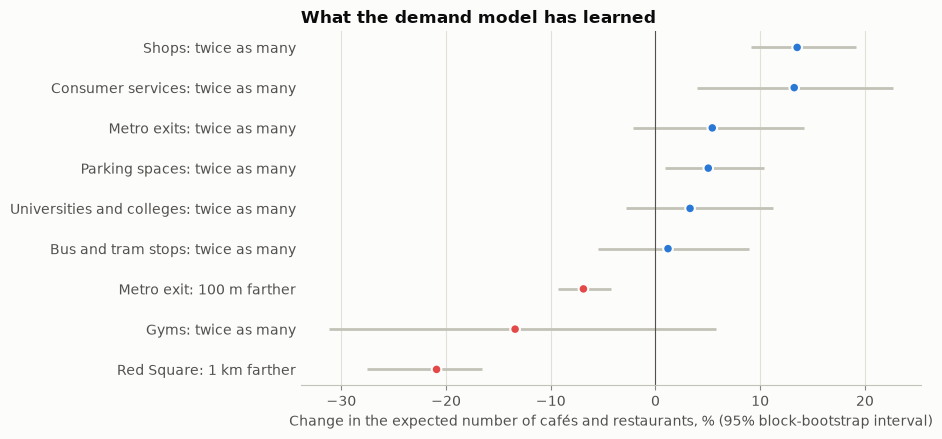

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.6))
positions = np.arange(len(effects))
ax.hlines(positions, effects["95% low"], effects["95% high"], color=AXIS, linewidth=2)
ax.scatter(effects["effect, %"], positions, s=48, color=[BLUE if v > 0 else RED for v in effects["effect, %"]],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.axvline(0, color=INK_2, linewidth=0.8)
ax.set_yticks(positions, effects["change"])
ax.set_xlabel("Change in the expected number of cafés and restaurants, % (95% block-bootstrap interval)")
ax.set_title("What the demand model has learned")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig6_model_effects")
plt.show()

## 7. Opportunity score and shortlist

The expected number of competitors of each cell comes from a model that never saw the cell's
block. The counts are strongly overdispersed (see the dispersion printed below), so the gap is
standardised with a negative binomial variance, `expected + expected² / θ`, instead of the Poisson
one; otherwise the busiest cells would dominate the ranking just because their counts are large.

The 300 m catchment is a convention, and the answer should not hinge on it (the modifiable areal
unit problem). The whole pipeline (features, models, gap, eligibility) is therefore run with 250,
300 and 400 m catchments, and the three gaps are averaged into the **opportunity score**.

A cell is **eligible** when, for at least two of the three catchments, it has a metro exit within
500 m, at least 10 shops and services around it (there is street retail, so there are commercial
premises) and at least the median expected demand. Eligible cells are ranked by the opportunity
score, most under-served first. The `competitors` and `expected` columns are for 300 m.

In [18]:
def opportunity(features, competitor_columns=("competitors",)):
    """Expected competitors (GLM, out of fold), gap score and eligibility."""
    y = features[list(competitor_columns)].sum(axis=1)
    X = design_matrix(features)
    expected = out_of_fold(glm(ALPHA), X, y)
    residual = y - expected
    theta = (expected ** 2).sum() / (residual ** 2 - expected).sum()  # negative binomial, method of moments
    gap = residual / np.sqrt(expected + expected ** 2 / theta)
    eligible = (
        (features["metro_distance"] <= 500)
        & (features["shops"] + features["services"] >= 10)
        & (expected >= expected.median())
    )
    return pd.DataFrame({"expected": expected, "gap": gap, "eligible": eligible}), theta


RADII = (250, 300, 400)
features_by_radius = {r: features if r == RADIUS_M else build_features(cells, **layers, radius=r) for r in RADII}


def multi_scale(competitor_columns=("competitors",)):
    """Gap averaged over the three catchments; eligible when eligible for at least two of them."""
    runs = {r: opportunity(features_by_radius[r], competitor_columns)[0] for r in RADII}
    score = pd.concat({r: runs[r]["gap"] for r in RADII}, axis=1).mean(axis=1)
    eligible = pd.concat({r: runs[r]["eligible"] for r in RADII}, axis=1).sum(axis=1) >= 2
    return score, eligible, runs


opportunity_score, eligible, runs = multi_scale()
run, theta = opportunity(features)
residual = y - run["expected"]
dispersion = (residual ** 2 / run["expected"]).sum() / (len(y) - X_linear.shape[1] - 1)
print(f"300 m: Pearson dispersion {dispersion:.1f} (1 would mean Poisson), negative binomial θ = {theta:.2f}")
print(f"{eligible.sum()} of {len(cells)} cells are eligible")

_, nearest_exit = nearest(xy_array(cells), metro_xy)
scores = cells[["address"]].assign(
    type=cluster,
    nearest_metro=metro["station"].to_numpy()[nearest_exit],
    metro_m=features["metro_distance"].round(),
    center_km=(features["center_distance"] / 1000).round(1),
    competitors=y,
    expected=run["expected"].round(1),
    score=opportunity_score.round(2),
    eligible=eligible,
    shops=features["shops"],
    services=features["services"],
    lat=cells["lat"].round(6),
    lon=cells["lon"].round(6),
)
shortlist = scores[scores["eligible"]].sort_values("score").head(10)
shortlist.insert(0, "rank", range(1, len(shortlist) + 1))
shortlist.drop(columns=["eligible", "lat", "lon"])

300 m: Pearson dispersion 6.1 (1 would mean Poisson), negative binomial θ = 3.54
101 of 364 cells are eligible


,rank,address,type,nearest_metro,metro_m,center_km,competitors,expected,score,shops,services
cell_id,,,,,,,,,,,
307,1,Savyolovsky Drive,Residential belt,Савёловская,376.0,4.6,1,10.7,-1.49,6,34
324,2,Festivalny Park,Residential belt,Марьина роща,253.0,4.3,1,10.4,-1.48,6,7
192,3,"Khoroshyovskoye Highway, вл1",Transit hubs,Беговая,4.0,5.3,4,14.1,-1.36,27,13
188,4,"Rogozhsky Val Street, 9/2с2",Central neighbourhoods,Площадь Ильича,439.0,3.8,4,14.9,-1.27,27,16
94,5,"Sharikopodshipnikovskaya Street, 11с1",Transit hubs,Дубровка,118.0,5.3,4,15.9,-1.23,1306,13
329,6,"Tsentralniy Administrative Okrug, Krasnoselski...",Residential belt,Красносельская,440.0,4.3,3,11.3,-1.12,26,9
129,7,"Krutitsky Val Street, 3с1",Transit hubs,Пролетарская,134.0,3.8,9,23.6,-1.09,27,30
325,8,Verzemneka Street,Residential belt,Рижская,465.0,4.2,5,11.3,-0.94,7,13
337,9,4th Maryinoy Roschi Drive,Transit hubs,Марьина роща,114.0,4.9,7,16.8,-0.94,54,12


### How stable is the shortlist?

Where the shortlisted cells rank among the eligible cells of each single catchment (empty: not
eligible with that catchment):

In [19]:
single_radius_ranks = pd.DataFrame(
    {f"rank at {r} m": runs[r]["gap"].where(runs[r]["eligible"]).rank(method="min") for r in RADII}
).loc[shortlist.index].astype("Int64")
shortlist[["rank", "address", "nearest_metro"]].join(single_radius_ranks)

,rank,address,nearest_metro,rank at 250 m,rank at 300 m,rank at 400 m
cell_id,,,,,,
307,1,Savyolovsky Drive,Савёловская,2,1,2
324,2,Festivalny Park,Марьина роща,<NA>,2,1
192,3,"Khoroshyovskoye Highway, вл1",Беговая,3,7,3
188,4,"Rogozhsky Val Street, 9/2с2",Площадь Ильича,4,6,4
94,5,"Sharikopodshipnikovskaya Street, 11с1",Дубровка,1,4,12
329,6,"Tsentralniy Administrative Okrug, Krasnoselski...",Красносельская,9,8,10
129,7,"Krutitsky Val Street, 3с1",Пролетарская,7,9,9
325,8,Verzemneka Street,Рижская,5,15,18
337,9,4th Maryinoy Roschi Drive,Марьина роща,<NA>,11,15


The competitor definition is a choice too: OpenStreetMap tags some coffee counters as fast food.
Counting fast food as competitors as well:

In [20]:
fast_food_score, fast_food_eligible, _ = multi_scale(("competitors", "fast_food"))
fast_food_top = fast_food_score[fast_food_eligible].nsmallest(10).index
kept = shortlist.index.intersection(fast_food_top)
print(f"{len(kept)} of the 10 shortlisted cells stay in the top 10: "
      + ", ".join(f"#{rank}" for rank in shortlist.loc[kept, "rank"]))
print("New entries:", ", ".join(cells.loc[fast_food_top.difference(shortlist.index), "address"]))

6 of the 10 shortlisted cells stay in the top 10: #1, #2, #3, #4, #6, #7
New entries: Kutuzovsky Avenue, 35, Goncharnaya Embankment, Stroykovskaya Street, 10, Sergeya Makeyeva Street, 12


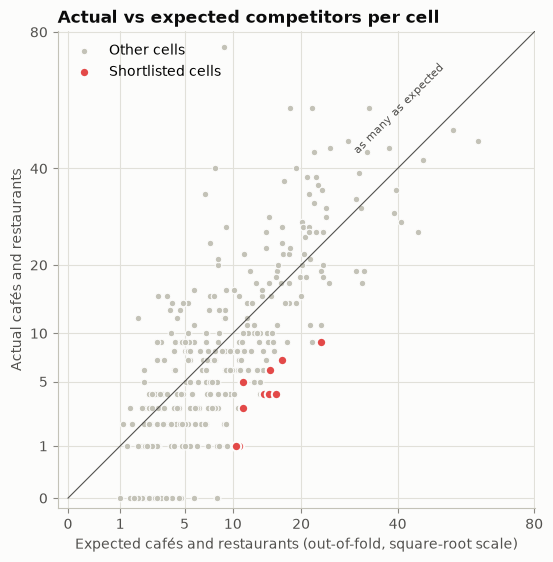

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 6.2))
others = scores.drop(shortlist.index)
ax.scatter(np.sqrt(others["expected"]), np.sqrt(others["competitors"]), s=22, color=AXIS, edgecolor=SURFACE,
           linewidth=0.8, label="Other cells")
ax.scatter(np.sqrt(shortlist["expected"]), np.sqrt(shortlist["competitors"]), s=46, color=RED, edgecolor=SURFACE,
           linewidth=1.5, label="Shortlisted cells", zorder=3)
limit = np.sqrt(max(scores["expected"].max(), scores["competitors"].max())) + 0.3
ax.plot([0, limit], [0, limit], color=INK_2, linewidth=0.8)
ax.annotate("as many as expected", (limit * 0.72, limit * 0.72), xytext=(-4, 6), textcoords="offset points",
            rotation=45, color=INK_2, fontsize=8, ha="center")
ticks = [0, 1, 5, 10, 20, 40, 80]
ax.set_xticks(np.sqrt(ticks), ticks)
ax.set_yticks(np.sqrt(ticks), ticks)
ax.set_xlim(-0.2, limit)
ax.set_ylim(-0.2, limit)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Expected cafés and restaurants (out-of-fold, square-root scale)")
ax.set_ylabel("Actual cafés and restaurants")
ax.set_title("Actual vs expected competitors per cell")
ax.legend(loc="upper left")
save(fig, "fig7_expected_vs_actual")
plt.show()

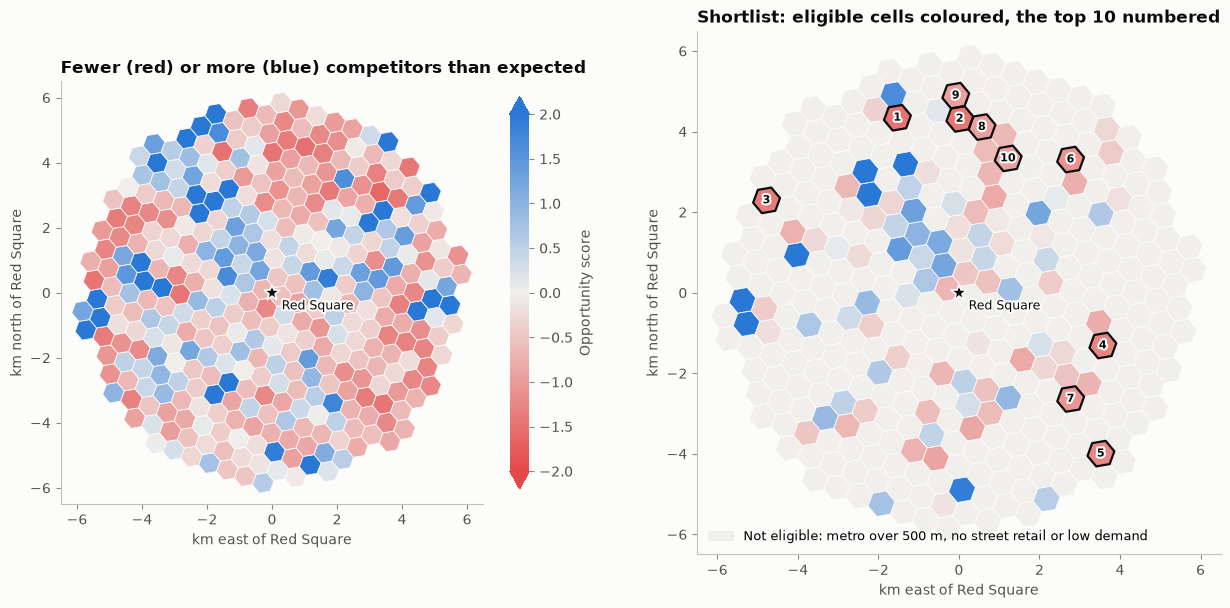

In [22]:
score_norm = Normalize(vmin=-2, vmax=2)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))
tiles = hex_map(axes[0], scores["score"], DIVERGING, score_norm, "Fewer (red) or more (blue) competitors than expected")
colorbar = fig.colorbar(tiles, ax=axes[0], shrink=0.75, extend="both")
colorbar.set_label("Opportunity score", color=INK_2)
colorbar.outline.set_visible(False)

hex_map(axes[1], np.zeros(len(cells)), ListedColormap([NEUTRAL]), Normalize(0, 1),
        "Shortlist: eligible cells coloured, the top 10 numbered")
tiles = PolyCollection(HEX_KM[scores["eligible"].to_numpy()], array=scores.loc[scores["eligible"], "score"].to_numpy(),
                       cmap=DIVERGING, norm=score_norm, edgecolor=SURFACE, linewidth=0.6)
axes[1].add_collection(tiles)
top = PolyCollection(HEX_KM[[cells.index.get_loc(i) for i in shortlist.index]], facecolor="none", edgecolor=INK,
                     linewidth=1.6)
axes[1].add_collection(top)
for cell_id, row in shortlist.iterrows():
    x, y_km = CELL_KM[cells.index.get_loc(cell_id)]
    axes[1].text(x, y_km, str(row["rank"]), ha="center", va="center", fontsize=8, fontweight="bold", color=INK,
                 path_effects=HALO)
axes[1].legend(handles=[Patch(color=NEUTRAL, label="Not eligible: metro over 500 m, no street retail or low demand")],
               loc="lower left", fontsize=9)
save(fig, "fig8_opportunity_map")
plt.show()

### Interactive map of the recommendations

Hover a cell for its numbers; the numbered markers are the shortlist. The map is also saved as
`report/cafe_opportunity_map.html`.

In [23]:
score_colors = bcm.LinearColormap([RED, NEUTRAL, BLUE], vmin=-2, vmax=2,
                                  caption="Opportunity score: red = fewer cafés and restaurants than expected")
map_table = scores.assign(
    eligible=scores["eligible"].map({True: "yes", False: "no"}),
)[["address", "type", "nearest_metro", "metro_m", "competitors", "expected", "score", "eligible"]]
opportunity_map = base_map()
hex_layer(map_table, scores["score"].clip(-2, 2).map(score_colors), list(map_table.columns),
          ["Address", "Type", "Nearest metro", "Metro exit, m", "Cafés and restaurants", "Expected", "Score",
           "Eligible"], "Opportunity score", opacity=0.6).add_to(opportunity_map)
shortlist_layer = folium.FeatureGroup(name="Shortlist")
for _, row in shortlist.iterrows():
    popup = (f"<b>#{row['rank']} {escape(row['address'])}</b><br>Metro {escape(row['nearest_metro'])}, "
             f"{row['metro_m']:.0f} m<br>{row['competitors']} cafés and restaurants within 300 m, "
             f"{row['expected']:.0f} expected<br>{row['shops']} shops, {row['services']} services")
    folium.Marker(
        [row["lat"], row["lon"]],
        icon=folium.DivIcon(
            html=f'<div style="width:24px;height:24px;border-radius:12px;background:{INK};color:{SURFACE};'
                 f'font:600 12px/24px system-ui,sans-serif;text-align:center">{row["rank"]}</div>',
            icon_size=(24, 24), icon_anchor=(12, 12)),
        tooltip=f"#{row['rank']} {escape(row['address'])}",
        popup=folium.Popup(popup, max_width=320),
    ).add_to(shortlist_layer)
shortlist_layer.add_to(opportunity_map)
score_colors.add_to(opportunity_map)
folium.LayerControl(collapsed=False).add_to(opportunity_map)
opportunity_map.save(REPORT / "cafe_opportunity_map.html")

scores.to_csv(REPORT / "cell_scores.csv", index_label="cell_id")
shortlist.drop(columns=["eligible"]).to_csv(REPORT / "shortlist.csv", index_label="cell_id")
opportunity_map

## 8. Results and discussion

### Results

* **The market.** Within 6 km of Red Square OpenStreetMap lists 6,121 catering venues, 3,933 of
  them cafés and restaurants. Chains with five or more outlets run 22% of the cafés and
  restaurants; the largest ones sell coffee.
* **Where cafés are.** Competitor density rises with consumer services (Spearman ρ = 0.62),
  shops (0.56), parking spaces (0.47) and metro exits (0.42), and falls with the distance to the
  nearest metro exit (−0.53) and to Red Square (−0.58).
* **Four types of places.** k-means splits the 364 cells into transit hubs (52), central
  neighbourhoods (82), the residential belt (152) and parks, rail and industrial land (78).
* **Demand model.** The footfall generators explain 58% of the Poisson deviance of the competitor
  counts under spatial cross-validation (Poisson GLM; gradient boosting reaches 54%). Each
  kilometre away from Red Square takes about 21% off the expected number of cafés and restaurants,
  each 100 m away from the nearest metro exit about 7%; twice as many shops add about 14%, twice
  as many consumer services about 13%, twice the parking about 5%. The effects of bus stops,
  universities, the number of metro exits and gyms cannot be told apart from zero.
* **Shortlist.** 101 cells pass the eligibility filters. The ten with the largest shortfall of
  competitors (counts and expectations for the 300 m catchment):

In [24]:
summary_columns = ["rank", "address", "nearest_metro", "metro_m", "center_km", "competitors", "expected", "score"]
shortlist[summary_columns].set_index("rank")

,address,nearest_metro,metro_m,center_km,competitors,expected,score
rank,,,,,,,
1,Savyolovsky Drive,Савёловская,376.0,4.6,1,10.7,-1.49
2,Festivalny Park,Марьина роща,253.0,4.3,1,10.4,-1.48
3,"Khoroshyovskoye Highway, вл1",Беговая,4.0,5.3,4,14.1,-1.36
4,"Rogozhsky Val Street, 9/2с2",Площадь Ильича,439.0,3.8,4,14.9,-1.27
5,"Sharikopodshipnikovskaya Street, 11с1",Дубровка,118.0,5.3,4,15.9,-1.23
6,"Tsentralniy Administrative Okrug, Krasnoselski...",Красносельская,440.0,4.3,3,11.3,-1.12
7,"Krutitsky Val Street, 3с1",Пролетарская,134.0,3.8,9,23.6,-1.09
8,Verzemneka Street,Рижская,465.0,4.2,5,11.3,-0.94
9,4th Maryinoy Roschi Drive,Марьина роща,114.0,4.9,7,16.8,-0.94


### Discussion

**The historic core is taken.** None of the ten cells lies inside the Garden Ring: the centre
already has as many cafés as its footfall generators suggest, or more. All shortlisted cells are
3.6-5.3 km from Red Square, around the Third Ring Road, within 470 m of a metro exit.

**Two kinds of opportunity.**

* *Almost no competitors yet* (#1 Savyolovskaya, #2 Maryina Roshcha): one café or restaurant
  within 300 m where about ten are expected. #1 sits by the Savyolovsky electronics market (29 of
  its 34 consumer services are electronics repair counters). A neighbourhood coffee shop or
  bakery-café would have the street to itself.
* *Busy places that are under-served for their size* (#3-#10): three to nine venues where 11-24
  are expected, around transport interchanges and markets: Begovaya, Ploshchad Ilyicha, the
  Dubrovka clothing market, Krasnoselskaya, Proletarskaya, Rizhskaya, Maryina Roshcha and Prospekt
  Mira. These suit a larger café or a coffee-to-go counter for commuters and shoppers.

**The most robust candidates** are #1 Savyolovskaya, #3 Begovaya, #4 Ploshchad Ilyicha,
#6 Krasnoselskaya and #7 Proletarskaya: they are eligible with every catchment, rank in the top 12
with each one and stay in the top 10 when fast food counts as competition too. #5 Dubrovka is as
stable across catchments but drops out once its 11 fast food outlets around the market are counted.
The bottom of the list is a near tie (#8-#10 score −0.93 to −0.94, with other cells close behind).

**What the model does not see.** The cells with the most surplus competitors show the limits of
the footfall layers:

In [25]:
scores.sort_values("score", ascending=False).head(6)[
    ["address", "nearest_metro", "type", "competitors", "expected", "score"]
]

,address,nearest_metro,type,competitors,expected,score
cell_id,,,,,,
254,"Miusskaya Square, 5",Белорусская,Central neighbourhoods,75,9.0,12.61
334,"Novodmitrovskaya Street, 2к7",Дмитровская,"Parks, rail and industrial land",12,1.8,5.67
96,1st Krasnogvardeysky Drive,Деловой центр,Transit hubs,40,8.0,5.64
78,Testovskaya Street,Международная,Central neighbourhoods,34,6.9,5.30
59,"Kutuzovsky Avenue, 32к2",Кутузовская,"Parks, rail and industrial land",15,3.0,4.45
273,"Novoslobodskaya Street, 16",Менделеевская,Transit hubs,56,18.2,3.84


The Depo food mall near Belorusskaya (75 venues where 9 are expected), the Moscow City towers
(Delovoy Tsentr, Mezhdunarodnaya) and the Khlebozavod creative cluster near Dmitrovskaya: food
halls, offices and destination venues draw far more cafés than shops and metro exits predict. The
same blind spot can make a place look under-served when its demand comes from something the data
does not hold.

**Limitations.**

* The footfall layers are from 2019 and the catering snapshot from 2026. Stations opened after
  2019 (the rest of the Big Circle Line, the MCD lines) are missing from the metro layer, and the
  shops and services have surely changed since. Refreshing these layers is the first improvement
  to make.
* OpenStreetMap is incomplete in places and tags inconsistently (some coffee counters are fast
  food). Cafés inside markets and malls are the most likely to be missing, which matters for
  Dubrovka.
* Competitors are counted, not weighed: a ten-seat coffee counter counts as much as a 200-seat
  restaurant, and price level and concept are ignored.
* There is no data on rents, pedestrian counts, office floor space or incomes; the distance to Red
  Square stands in for tourists and offices.
* The shops layer holds 22,109 of the register's 60,320 shops.

**Next steps.** Visit the shortlisted places at peak hours, check vacant premises and asking rents,
add office and footfall data (business centres, mobile-operator counts) and refresh the 2019 layers.

## 9. Conclusion

The project looked for places in central Moscow where a new café would share the local footfall
with fewer competitors than usual. Moscow open data on transport, retail and services and
OpenStreetMap catering data were combined on a grid of 364 cells, and a count model learned how
many cafés and restaurants a place normally has given what surrounds it (58% of the deviance
explained under spatial cross-validation). Comparing that expectation with reality shows a
saturated historic core and, 3.5-5.5 km from Red Square, a belt of places next to metro stations
with markedly fewer cafés than expected. The strongest candidates are around Savyolovskaya,
Begovaya, Ploshchad Ilyicha, Krasnoselskaya and Proletarskaya.

The analysis narrows the search from the whole centre to about ten places. The final choice needs
what open data cannot give: a walk around at rush hour, the rent and the concept.